# SILVA Operator Options

The reference graph model keeps the Figure 1 decomposition explicit:

$$
z_{k+1}
=
(1-\alpha)z_k
+
\alpha\Phi\{S_\theta(x)+L_\theta(\tanh z_k,E)+G_\theta(\tanh z_k,b)\}.
$$

`hidden_dim`, `stack_alphas`, `graph_mode`, `attention_mode`, solver settings,
and readout dimensions are constructor arguments.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
from silva_networks import (
    SILVAGraphPresetNetwork,
    SILVAMolecularRegressor,
    SILVAVisionVectorClassifier,
    SolverConfig,
    damped_spectral_radius,
    molecular_to_silva_graph,
    tabular_to_silva_graph,
)

torch.manual_seed(6)
x = torch.randn(9, 5)
y = (x[:, 0] > 0).long()
edge_index = torch.tensor(
    [[0, 1, 2, 3, 4, 5, 6, 7, 8],
     [1, 2, 3, 4, 5, 6, 7, 8, 0]],
    dtype=torch.long,
)

The SILVA ablations are available through operator names. Each row below
uses the same input graph and changes only the local or global interaction.
The ablation value is the string `"none"`: it removes that branch from
$L_\theta$ or $G_\theta$. Solver self-persistence
$(1-\alpha)z_k$ is still present, so the no-local/no-global case is
stimulus plus damped recurrent persistence.

In [3]:
cases = [
    ("full", "GAT", "simple"),
    ("local_only", "GAT", "none"),
    ("global_only", "none", "simple"),
    ("static_global", "GAT", "static"),
    ("topk_global", "GAT", "topk"),
]

case_rows = []
for name, graph_mode, attention_mode in cases:
    model = SILVAGraphPresetNetwork(
        in_dim=5,
        hidden_dim=[12, 8],
        out_dim=2,
        task="node",
        graph_mode=graph_mode,
        attention_mode=attention_mode,
        num_heads=2,
        k_neighbors=3,
        stack_alphas=[0.5, 0.2],
        max_iter=3,
    )
    result = model(x, edge_index=edge_index, return_results=True)
    residuals = [float(r.residual) for r in result.solver_results]
    case_rows.append({"case": name, "shape": tuple(result.output.shape), "residuals": residuals})
    print(name, tuple(result.output.shape), [round(value, 5) for value in residuals])
case_rows

full (9, 2) [5.69209, 5.83524]
local_only (9, 2) [4.29137, 5.87878]
global_only (9, 2) [2.68777, 5.45418]
static_global (9, 2) [4.39082, 6.33538]
topk_global (9, 2) [6.57354, 6.09027]


[{'case': 'full',
  'shape': (9, 2),
  'residuals': [5.692088603973389, 5.835236072540283]},
 {'case': 'local_only',
  'shape': (9, 2),
  'residuals': [4.2913689613342285, 5.878783702850342]},
 {'case': 'global_only',
  'shape': (9, 2),
  'residuals': [2.6877706050872803, 5.454184055328369]},
 {'case': 'static_global',
  'shape': (9, 2),
  'residuals': [4.390822887420654, 6.335383892059326]},
 {'case': 'topk_global',
  'shape': (9, 2),
  'residuals': [6.573538780212402, 6.090270519256592]}]

The bar plot compares the largest final residual across the ablation stack.
It is a quick numerical check that changing an operator still produces a
finite solved state on the same input.

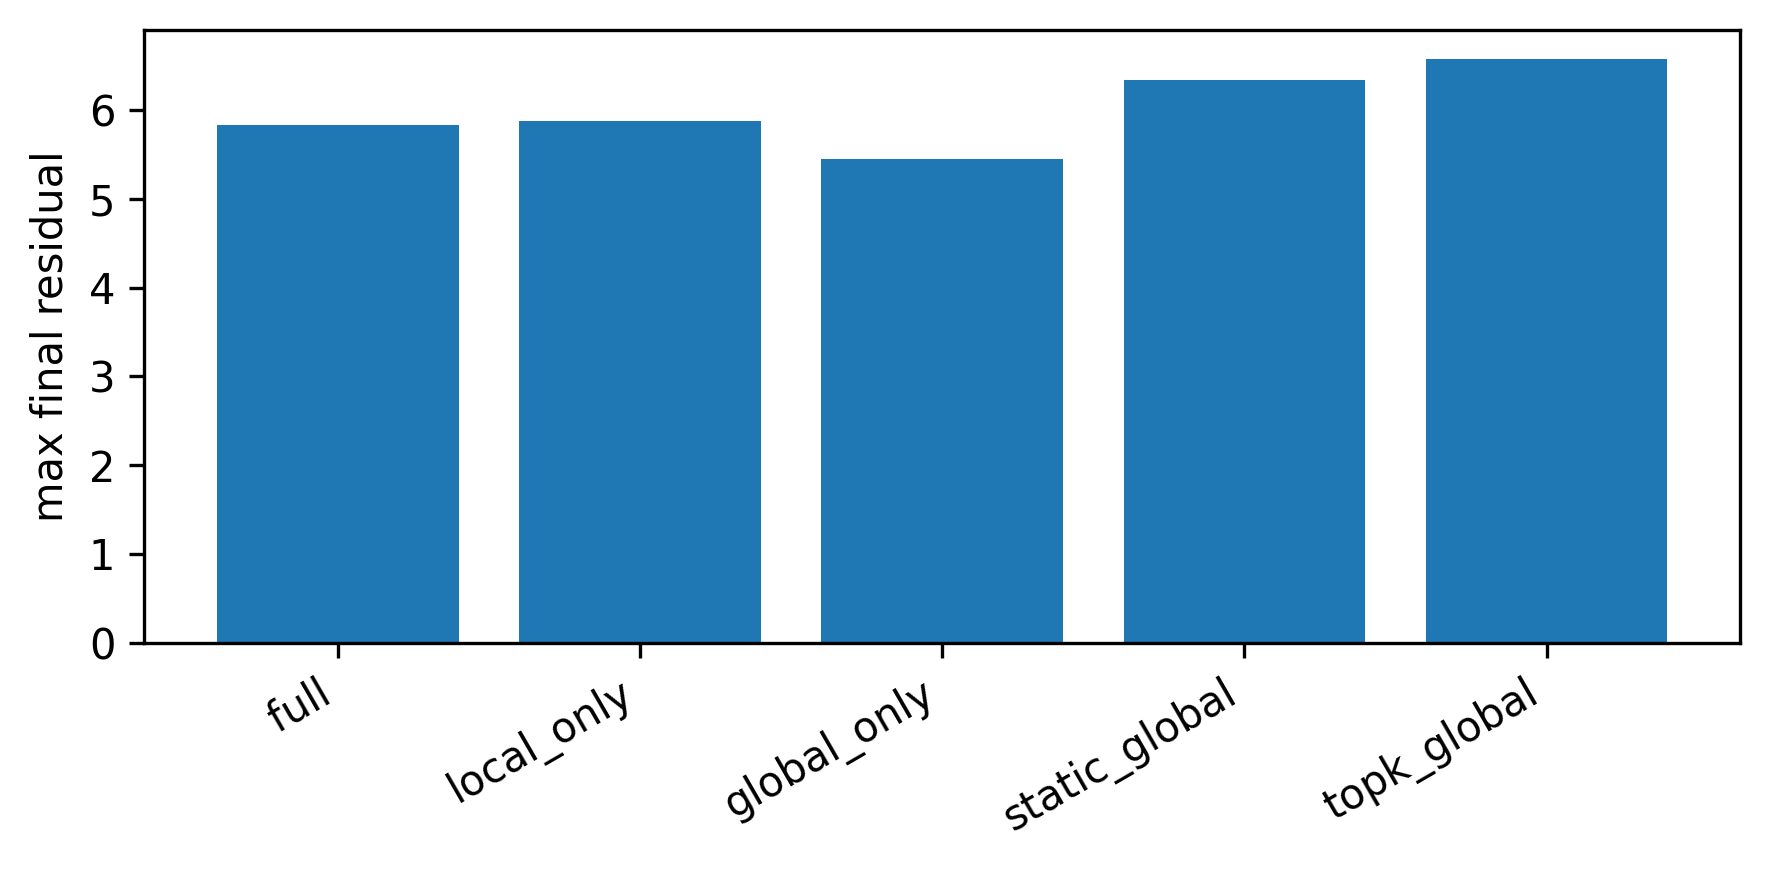

In [4]:
plt.figure(figsize=(6, 3))
plt.bar([row["case"] for row in case_rows], [max(row["residuals"]) for row in case_rows])
plt.xticks(rotation=30, ha="right")
plt.ylabel("max final residual")
plt.tight_layout()

The generic API accepts per-layer solvers and custom branches. A custom branch
only has to return a tensor shaped like the recurrent state.

In [5]:
class BiasLocal(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(dim))

    def forward(self, z, edge_index=None, edge_attr=None, batch=None):
        return torch.tanh(z + self.bias)

from silva_networks import SILVAGraphNetwork

custom = SILVAGraphNetwork(
    in_dim=5,
    hidden_dims=[12, 8, 8],
    out_dim=2,
    task="node",
    local=lambda dim, index: BiasLocal(dim),
    global_term=["mean", "simple", "topk_attention"],
    global_kwargs=[None, None, {"k": 4}],
    self_term=[None, "linear", None],
    config=[
        SolverConfig(solver="picard", max_iter=3, alpha=0.5),
        SolverConfig(solver="anderson", max_iter=3, alpha=0.35, history=3),
        SolverConfig(solver="broyden", max_iter=3, alpha=0.25),
    ],
)
custom(x, edge_index=edge_index).shape

torch.Size([9, 2])

Molecular SILVA accepts categorical atom/bond ids or continuous feature
vectors. The continuous path uses explicit input projectors.

In [6]:
mol = molecular_to_silva_graph(
    x=torch.randn(5, 3),
    edge_index=torch.tensor([[0, 1, 2, 3, 4, 1], [1, 2, 0, 4, 3, 0]]),
    edge_attr=torch.randn(6, 2),
    batch=torch.tensor([0, 0, 0, 1, 1]),
    y=torch.tensor([0.3, -0.1]),
)
molecular_model = SILVAMolecularRegressor(
    hidden_dim=[9, 6],
    atom_feature_dim=3,
    bond_feature_dim=2,
    num_heads=3,
    alphas=(0.5, 0.2),
    max_iter=2,
    dropout=0.0,
    spectral_norm=False,
)
molecular_model(**mol.model_kwargs(), return_results=True).output

tensor([-0.1630, -0.0136], grad_fn=<SqueezeBackward1>)

Lyapunov-style and Jacobian diagnostics can be run on any transition. Here the
spectral-radius estimate is applied to the first SILVA layer transition.

In [7]:
layer = SILVAGraphPresetNetwork(
    in_dim=5,
    hidden_dim=8,
    out_dim=2,
    stack_alphas=[0.5],
    num_heads=2,
    max_iter=3,
).layers[0]
z0 = torch.zeros(x.shape[0], 8)
z_star = layer(x, edge_index=edge_index)
rho = damped_spectral_radius(lambda z: layer.f(z, x, edge_index=edge_index), z_star, alpha=0.5, iters=3)
rho

0.755165159702301

## Citation and Sources

If this notebook or package is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.0.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770099
```

When the work is connected to the SILVA Networks paper, cite the paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background references used in the tutorial suite include:

- Deep Equilibrium Models, Bai, Kolter, and Koltun, NeurIPS 2019:
  https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models, Bai, Koltun, and Kolter, NeurIPS 2020:
  https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization, Bai, Koltun, and
  Kolter, ICML 2021: https://arxiv.org/abs/2106.14342
- Graph Attention Networks, Velickovic et al., ICLR 2018:
  https://arxiv.org/abs/1710.10903
- Attention Is All You Need, Vaswani et al., 2017:
  https://arxiv.org/abs/1706.03762